# Telco Customer Churn Prediction

**End-to-End Machine Learning Project**

## 1. Business Understanding

### Business Problem

Customer churn is one of the biggest challenges in the telecom industry. Acquiring a new customer costs **5 to 7 times more** than retaining an existing one. When customers leave, the company loses recurring revenue and the investment made in onboarding them.

### Objective

Build a machine learning model that can predict whether a customer is likely to churn based on their demographics, account information, and services they use.

### Business Goal

- Identify customers who are at high risk of leaving.
- Understand the key factors that drive churn.
- Provide actionable recommendations to the business team to improve customer retention.

---
## 2. Data Loading

In [1]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
## 3. Data Understanding

In [2]:
df.shape

(7043, 21)

In [3]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

---
## 4. Data Cleaning

### Handle Incorrect Data Types

`TotalCharges` should be numeric but it is stored as object. Let's check why.

In [9]:
df['TotalCharges'].dtype

dtype('O')

In [10]:
import numpy as np

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()

np.int64(11)

There are 11 rows where `TotalCharges` had blank spaces, which got converted to NaN. These are likely new customers with very short tenure.

In [11]:
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


All of them have tenure = 0. Let's fill TotalCharges with 0 for these customers.

In [12]:
df['TotalCharges'].fillna(0, inplace=True)

C:\Users\aryan\AppData\Local\Temp\ipykernel_18408\171940771.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [13]:
df.isnull().sum().sum()

np.int64(0)

### Convert SeniorCitizen to categorical

`SeniorCitizen` is stored as 0/1 integers. Let's convert it to Yes/No for consistency with other columns.

In [14]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

In [15]:
df.duplicated().sum()

np.int64(0)

No duplicate rows found. The data is now clean.

---
## 5. Exploratory Data Analysis (EDA)

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

### 5.1 Churn Distribution

In [17]:
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f"\nChurn Rate: {churn_counts['Yes'] / len(df) * 100:.1f}%")

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.5%


C:\Users\aryan\AppData\Local\Temp\ipykernel_18408\1446614060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette=colors)


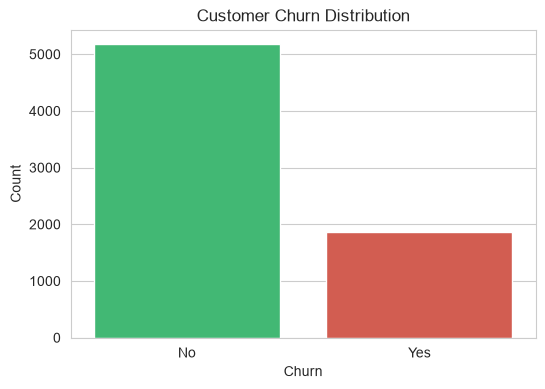

In [18]:
colors = ['#2ecc71', '#e74c3c']
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette=colors)
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

**Insight:** About 26.5% of customers have churned. The dataset is imbalanced with more non-churning customers.

### 5.2 Gender Distribution

C:\Users\aryan\AppData\Local\Temp\ipykernel_18408\11248851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df, palette='Set2', ax=axes[0])


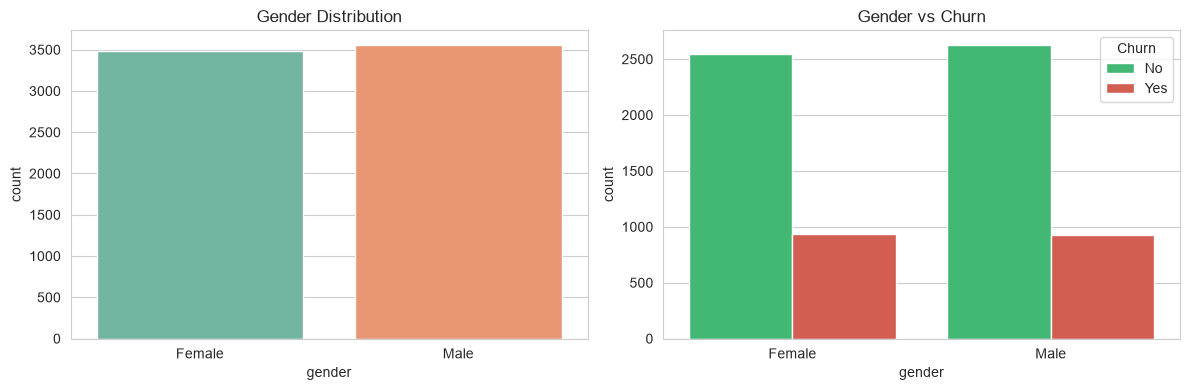

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='gender', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Gender Distribution')

sns.countplot(x='gender', hue='Churn', data=df, palette=colors, ax=axes[1])
axes[1].set_title('Gender vs Churn')

plt.tight_layout()
plt.show()

**Insight:** Gender distribution is almost equal. Churn rate is similar for both males and females, so gender alone is not a strong predictor of churn.

### 5.3 Senior Citizen

C:\Users\aryan\AppData\Local\Temp\ipykernel_18408\700466437.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='SeniorCitizen', data=df, palette='Set2', ax=axes[0])


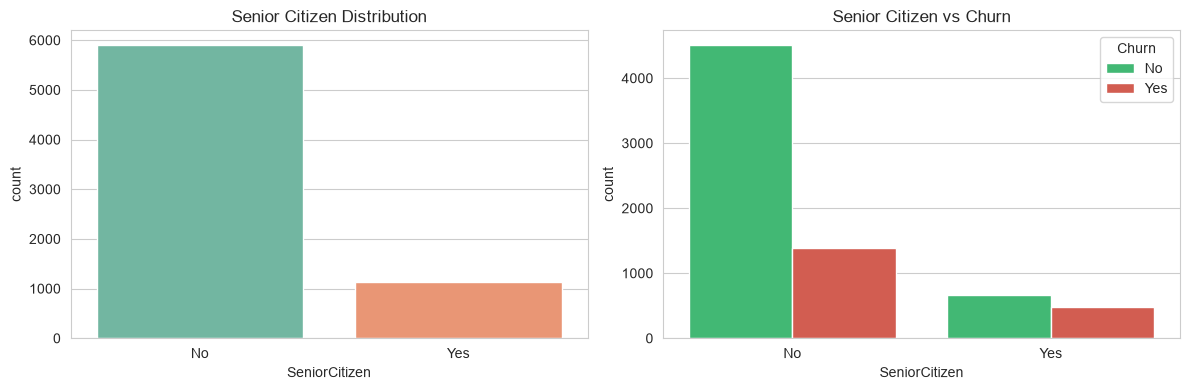

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='SeniorCitizen', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Senior Citizen Distribution')

sns.countplot(x='SeniorCitizen', hue='Churn', data=df, palette=colors, ax=axes[1])
axes[1].set_title('Senior Citizen vs Churn')

plt.tight_layout()
plt.show()

**Insight:** Senior citizens make up a small portion of the customer base but have a significantly higher churn rate compared to non-senior citizens.

### 5.4 Partner & Dependents

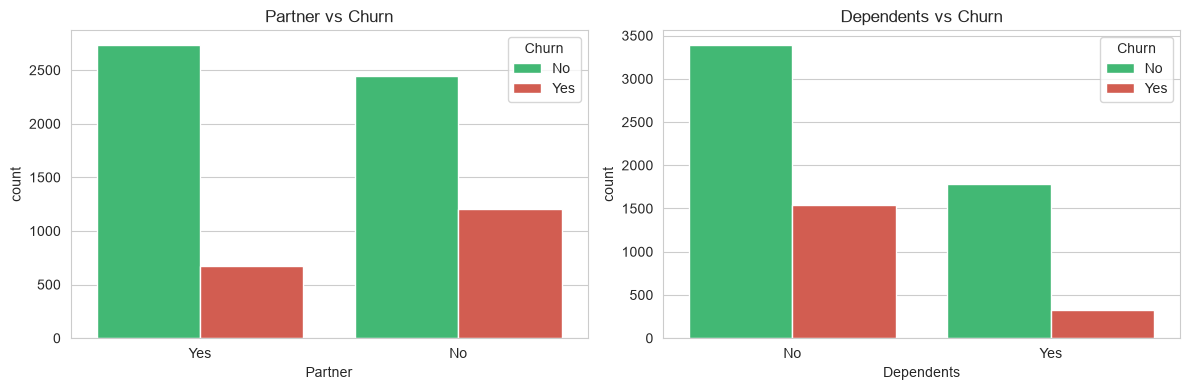

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='Partner', hue='Churn', data=df, palette=colors, ax=axes[0])
axes[0].set_title('Partner vs Churn')

sns.countplot(x='Dependents', hue='Churn', data=df, palette=colors, ax=axes[1])
axes[1].set_title('Dependents vs Churn')

plt.tight_layout()
plt.show()

**Insight:** Customers without a partner or without dependents are more likely to churn. Family ties seem to be a retention factor.

### 5.5 Contract Type

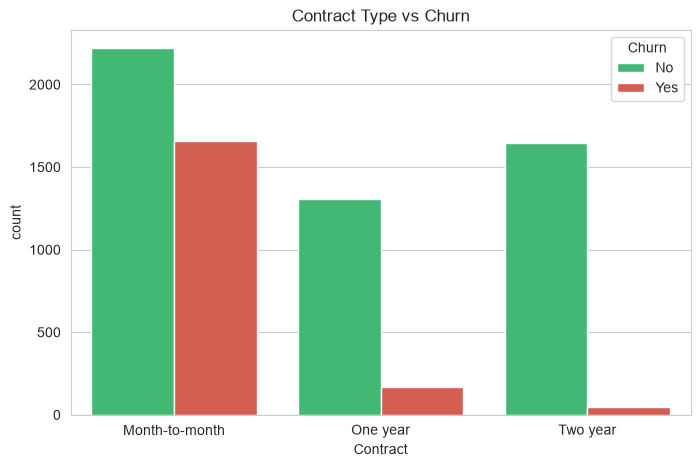

In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette=colors,
              order=['Month-to-month', 'One year', 'Two year'])
plt.title('Contract Type vs Churn')
plt.show()

**Insight:** Month-to-month customers churn the most. Long-term contracts (one year, two year) show much lower churn rates. This is one of the strongest predictors.

### 5.6 Internet Service

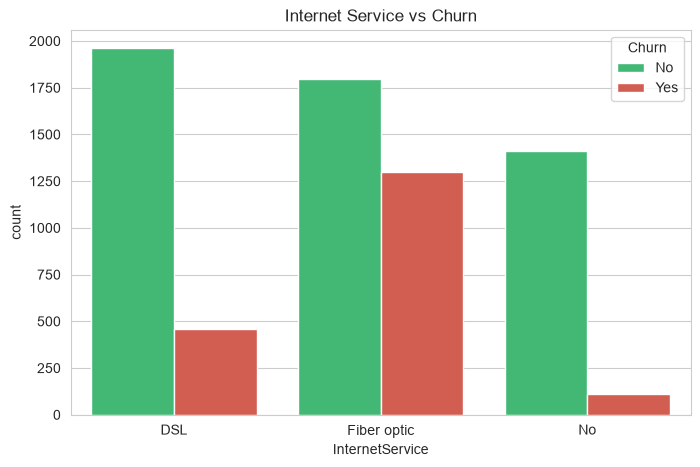

In [23]:
plt.figure(figsize=(8, 5))
sns.countplot(x='InternetService', hue='Churn', data=df, palette=colors)
plt.title('Internet Service vs Churn')
plt.show()

**Insight:** Customers with Fiber optic internet have the highest churn rate. This could be due to higher prices, service quality issues, or better alternatives available.

### 5.7 Payment Method

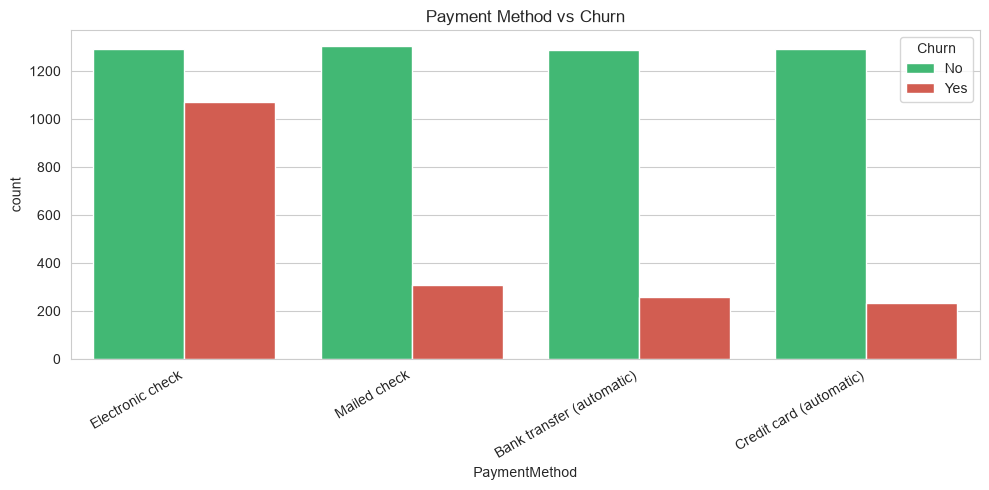

In [24]:
plt.figure(figsize=(10, 5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette=colors)
plt.title('Payment Method vs Churn')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Insight:** Customers using **Electronic check** have a noticeably higher churn rate. Automatic payment methods (bank transfer, credit card) show better retention.

### 5.8 Monthly Charges Distribution

C:\Users\aryan\AppData\Local\Temp\ipykernel_18408\1538727285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=colors, ax=axes[1])


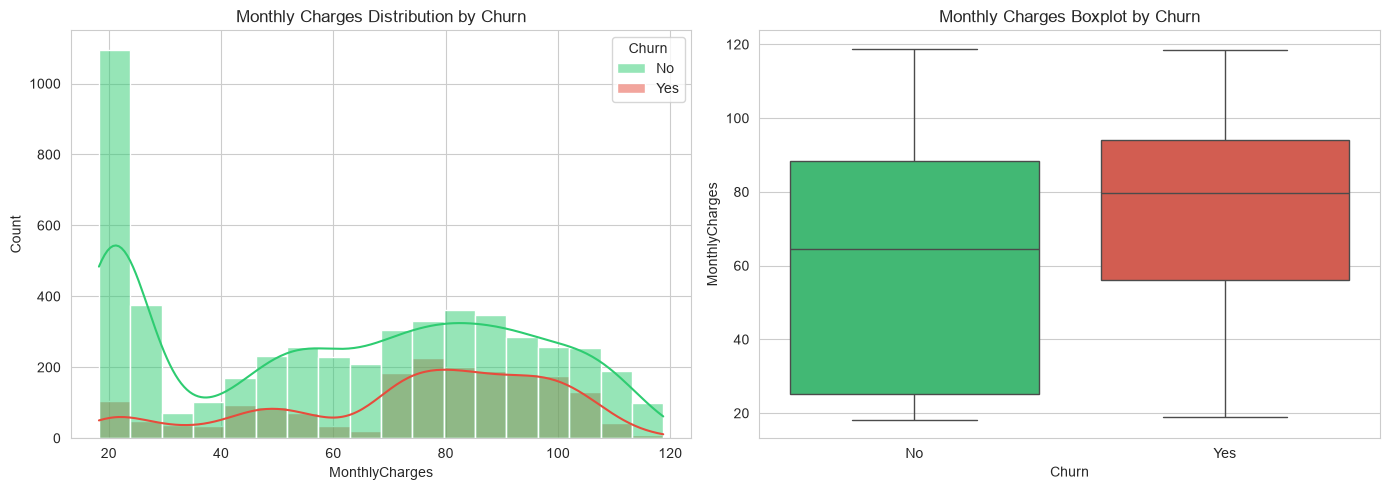

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, palette=colors, ax=axes[0])
axes[0].set_title('Monthly Charges Distribution by Churn')

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=colors, ax=axes[1])
axes[1].set_title('Monthly Charges Boxplot by Churn')

plt.tight_layout()
plt.show()

**Insight:** Churned customers tend to have higher monthly charges. Customers paying more might feel they're not getting enough value for the price.

### 5.9 Total Charges Distribution

C:\Users\aryan\AppData\Local\Temp\ipykernel_18408\1028561163.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='TotalCharges', data=df, palette=colors, ax=axes[1])


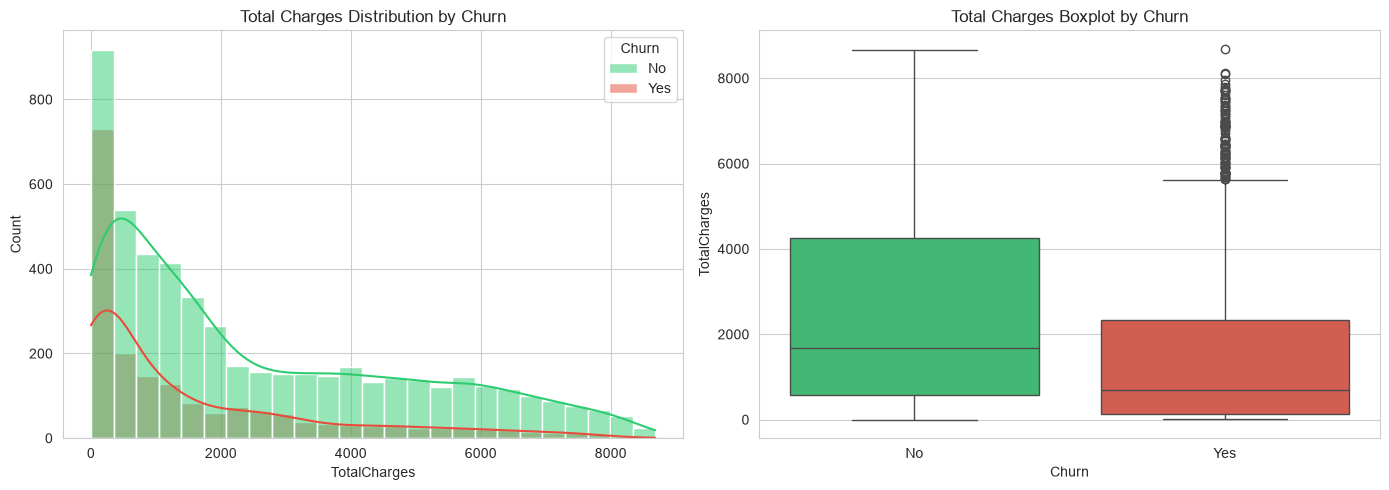

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='TotalCharges', hue='Churn', kde=True, palette=colors, ax=axes[0])
axes[0].set_title('Total Charges Distribution by Churn')

sns.boxplot(x='Churn', y='TotalCharges', data=df, palette=colors, ax=axes[1])
axes[1].set_title('Total Charges Boxplot by Churn')

plt.tight_layout()
plt.show()

**Insight:** Churned customers tend to have lower total charges, which means they leave early before spending much. Long-term customers who have spent more tend to stay.

### 5.10 Tenure Distribution

C:\Users\aryan\AppData\Local\Temp\ipykernel_18408\2520557455.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette=colors, ax=axes[1])


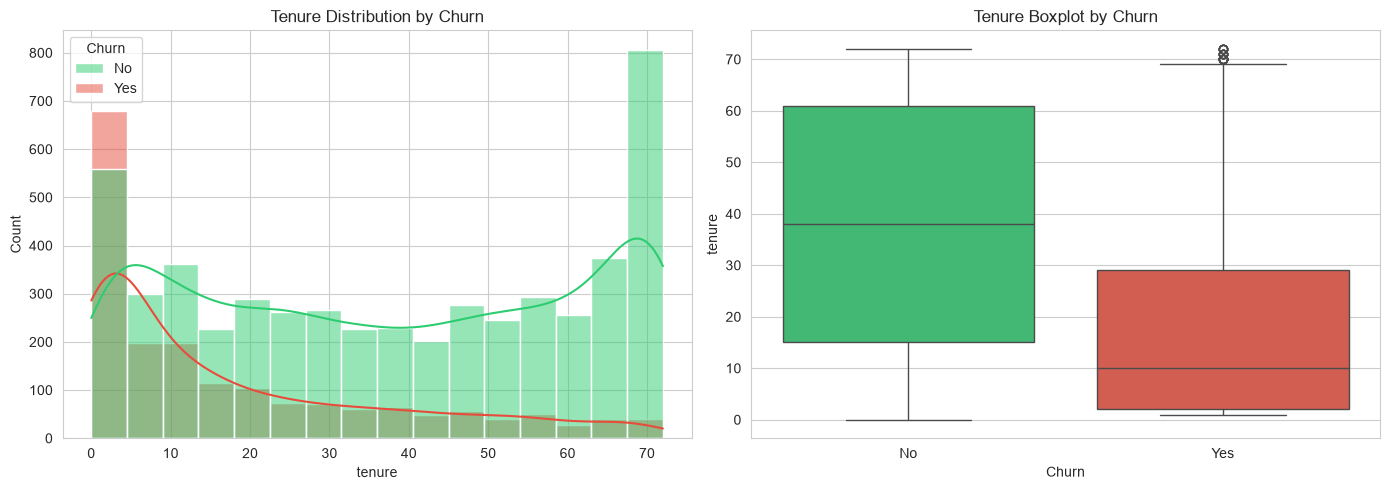

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='tenure', hue='Churn', kde=True, palette=colors, ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn')

sns.boxplot(x='Churn', y='tenure', data=df, palette=colors, ax=axes[1])
axes[1].set_title('Tenure Boxplot by Churn')

plt.tight_layout()
plt.show()

**Insight:** Customers with shorter tenure are far more likely to churn. Most churn happens in the first few months. The first year is critical for retention.

### 5.11 Phone Service & Multiple Lines

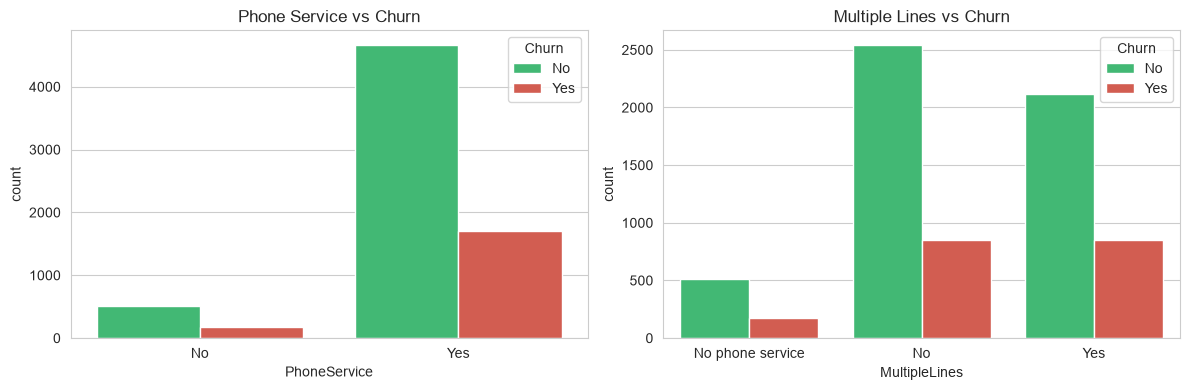

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='PhoneService', hue='Churn', data=df, palette=colors, ax=axes[0])
axes[0].set_title('Phone Service vs Churn')

sns.countplot(x='MultipleLines', hue='Churn', data=df, palette=colors, ax=axes[1])
axes[1].set_title('Multiple Lines vs Churn')

plt.tight_layout()
plt.show()

### 5.12 Online Security, Tech Support, and Streaming Services

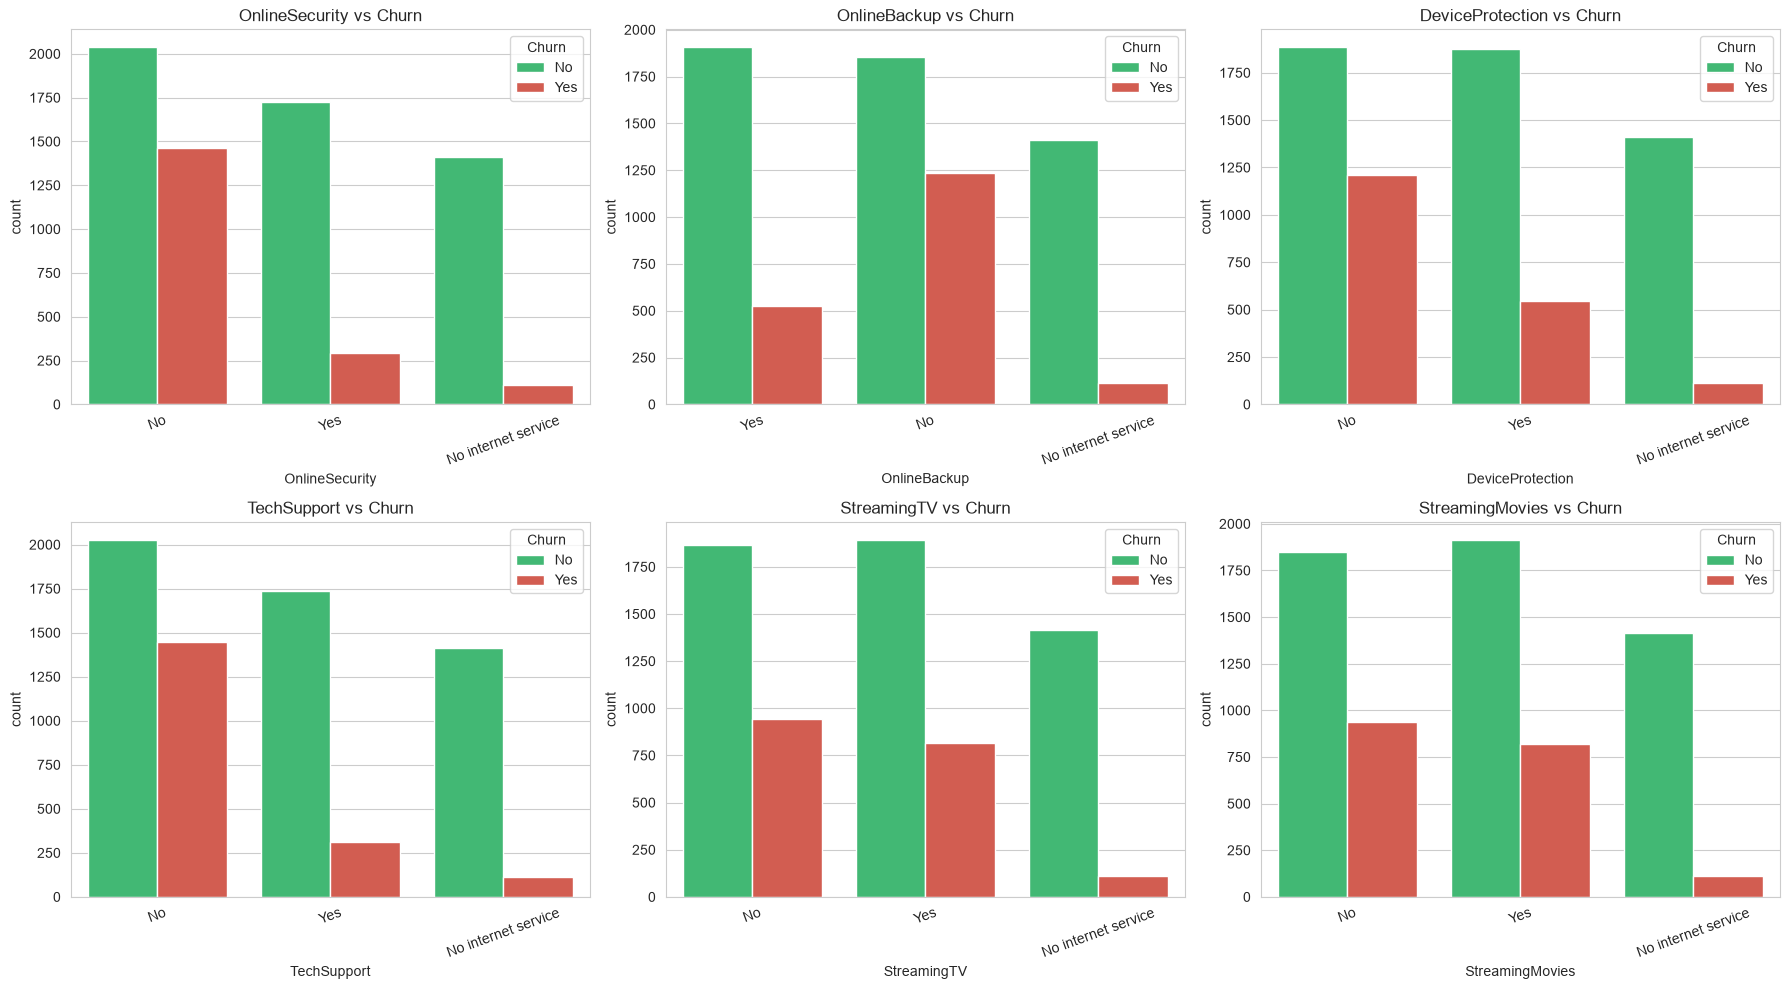

In [29]:
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(services):
    sns.countplot(x=col, hue='Churn', data=df, palette=colors, ax=axes[i])
    axes[i].set_title(f'{col} vs Churn')
    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Insight:** Customers without **Online Security** and **Tech Support** have higher churn rates. These add-on services act as retention levers.

### 5.13 Paperless Billing

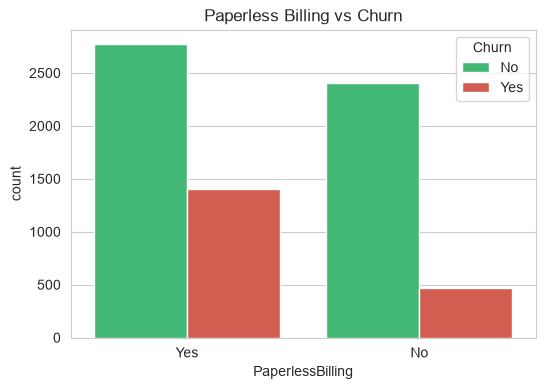

In [30]:
plt.figure(figsize=(6, 4))
sns.countplot(x='PaperlessBilling', hue='Churn', data=df, palette=colors)
plt.title('Paperless Billing vs Churn')
plt.show()

**Insight:** Customers with paperless billing have a higher churn rate. This could be because digitally engaged customers find it easier to switch providers.

### 5.14 Correlation Heatmap

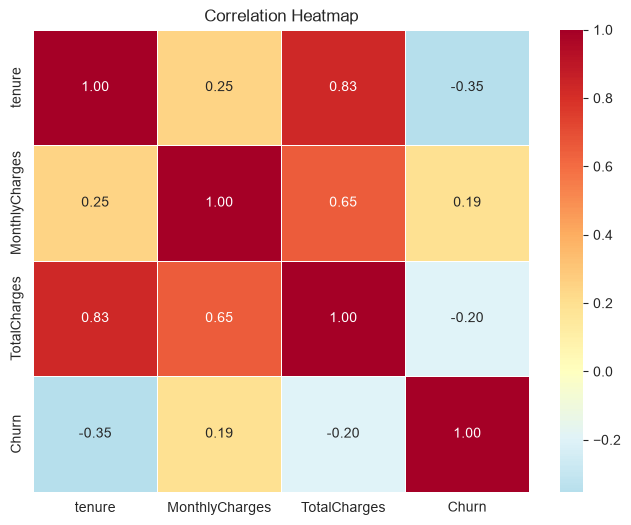

In [31]:
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
numeric_df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

**Insight:** 
- Tenure has a **negative correlation** with churn — longer tenure = less churn.
- Monthly charges have a **positive correlation** with churn — higher charges = more churn.
- Total charges and tenure are strongly correlated, which makes sense.

### 5.15 Churn Rate by Tenure Groups

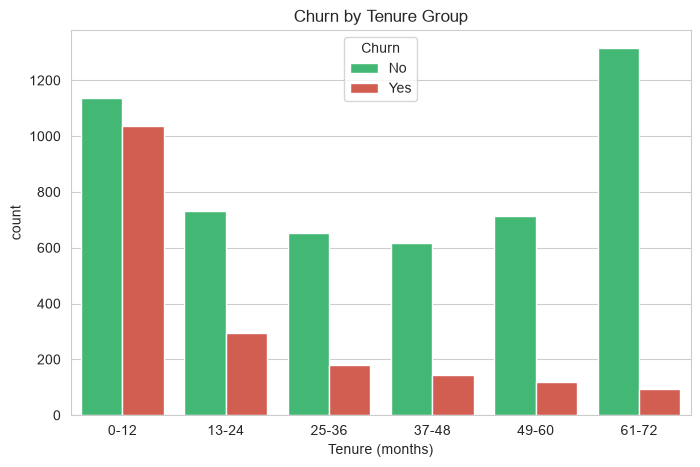

In [32]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 36, 48, 60, 72],
                            labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72'])

plt.figure(figsize=(8, 5))
sns.countplot(x='tenure_group', hue='Churn', data=df, palette=colors)
plt.title('Churn by Tenure Group')
plt.xlabel('Tenure (months)')
plt.show()

**Insight:** The first 12 months is the danger zone — most churning customers leave within this period. Retention efforts should focus heavily on new customers.

In [33]:
# Drop the temporary column
df.drop('tenure_group', axis=1, inplace=True)

---
## 6. Feature Engineering

### 6.1 Remove CustomerID

CustomerID is just a unique identifier and has no predictive power.

In [34]:
df_model = df.drop('customerID', axis=1)
df_model.shape

(7043, 20)

### 6.2 Encode Target Variable

In [35]:
df_model['Churn'] = df_model['Churn'].map({'No': 0, 'Yes': 1})
df_model['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

### 6.3 Encode Categorical Variables

We'll use one-hot encoding for categorical columns with more than 2 categories and label encoding for binary columns.

In [36]:
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns: {len(cat_cols)}")
print(cat_cols)

Categorical columns: 16
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [37]:
for col in cat_cols:
    print(f"{col}: {df_model[col].nunique()} unique values — {df_model[col].unique()}")

gender: 2 unique values — ['Female' 'Male']
SeniorCitizen: 2 unique values — ['No' 'Yes']
Partner: 2 unique values — ['Yes' 'No']
Dependents: 2 unique values — ['No' 'Yes']
PhoneService: 2 unique values — ['No' 'Yes']
MultipleLines: 3 unique values — ['No phone service' 'No' 'Yes']
InternetService: 3 unique values — ['DSL' 'Fiber optic' 'No']
OnlineSecurity: 3 unique values — ['No' 'Yes' 'No internet service']
OnlineBackup: 3 unique values — ['Yes' 'No' 'No internet service']
DeviceProtection: 3 unique values — ['No' 'Yes' 'No internet service']
TechSupport: 3 unique values — ['No' 'Yes' 'No internet service']
StreamingTV: 3 unique values — ['No' 'Yes' 'No internet service']
StreamingMovies: 3 unique values — ['No' 'Yes' 'No internet service']
Contract: 3 unique values — ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: 2 unique values — ['Yes' 'No']
PaymentMethod: 4 unique values — ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [38]:
df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)
df_encoded.shape

(7043, 31)

In [39]:
df_encoded.head()

,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,0,False,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,34,56.95,1889.50,0,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,45,42.30,1840.75,0,True,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,2,70.70,151.65,1,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


### 6.4 Prepare Features and Target

In [40]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (7043, 30)
Target shape: (7043,)


### 6.5 Train-Test Split

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 5634 samples
Test set: 1409 samples


### 6.6 Feature Scaling

We'll scale the numeric features. Tree-based models don't require scaling, but Logistic Regression benefits from it.

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

In [43]:
X_train.head()

,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0.102371,-0.521976,-0.262257,True,False,False,False,False,True,False,...,False,True,False,True,False,False,False,False,True,False
3151,-0.711743,0.337478,-0.503635,True,False,True,True,True,False,False,...,False,False,False,False,False,False,False,False,False,True
4860,-0.793155,-0.809013,-0.749883,True,False,True,True,False,True,False,...,False,False,False,False,False,True,False,False,False,True
3867,-0.263980,0.284384,-0.172722,False,False,True,False,True,False,False,...,False,True,False,True,False,True,True,True,False,False
3810,-1.281624,-0.676279,-0.989374,True,False,True,True,True,False,False,...,False,False,False,False,False,False,False,False,True,False


---
## 7. Machine Learning Models

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [45]:
results = []

### 7.1 Logistic Regression

In [46]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

results.append({'Model': 'Logistic Regression', 'Accuracy': lr_acc, 'Precision': lr_prec,
                'Recall': lr_rec, 'F1 Score': lr_f1})

print(f"Accuracy:  {lr_acc:.4f}")
print(f"Precision: {lr_prec:.4f}")
print(f"Recall:    {lr_rec:.4f}")
print(f"F1 Score:  {lr_f1:.4f}")

Accuracy:  0.8062
Precision: 0.6593
Recall:    0.5588
F1 Score:  0.6049


### 7.2 Decision Tree

In [47]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
dt_prec = precision_score(y_test, dt_pred)
dt_rec = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

results.append({'Model': 'Decision Tree', 'Accuracy': dt_acc, 'Precision': dt_prec,
                'Recall': dt_rec, 'F1 Score': dt_f1})

print(f"Accuracy:  {dt_acc:.4f}")
print(f"Precision: {dt_prec:.4f}")
print(f"Recall:    {dt_rec:.4f}")
print(f"F1 Score:  {dt_f1:.4f}")

Accuracy:  0.7317
Precision: 0.4946
Recall:    0.4866
F1 Score:  0.4906


### 7.3 Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

results.append({'Model': 'Random Forest', 'Accuracy': rf_acc, 'Precision': rf_prec,
                'Recall': rf_rec, 'F1 Score': rf_f1})

print(f"Accuracy:  {rf_acc:.4f}")
print(f"Precision: {rf_prec:.4f}")
print(f"Recall:    {rf_rec:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")

Accuracy:  0.7921
Precision: 0.6421
Recall:    0.4893
F1 Score:  0.5554


### 7.4 Gradient Boosting

In [49]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_acc = accuracy_score(y_test, gb_pred)
gb_prec = precision_score(y_test, gb_pred)
gb_rec = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)

results.append({'Model': 'Gradient Boosting', 'Accuracy': gb_acc, 'Precision': gb_prec,
                'Recall': gb_rec, 'F1 Score': gb_f1})

print(f"Accuracy:  {gb_acc:.4f}")
print(f"Precision: {gb_prec:.4f}")
print(f"Recall:    {gb_rec:.4f}")
print(f"F1 Score:  {gb_f1:.4f}")

Accuracy:  0.7977
Precision: 0.6540
Recall:    0.5053
F1 Score:  0.5701


### 7.5 Model Comparison

In [50]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.806246,0.659306,0.558824,0.604920
1,Gradient Boosting,0.797729,0.653979,0.505348,0.570136
2,Random Forest,0.792051,0.642105,0.489305,0.555387
3,Decision Tree,0.731725,0.494565,0.486631,0.490566


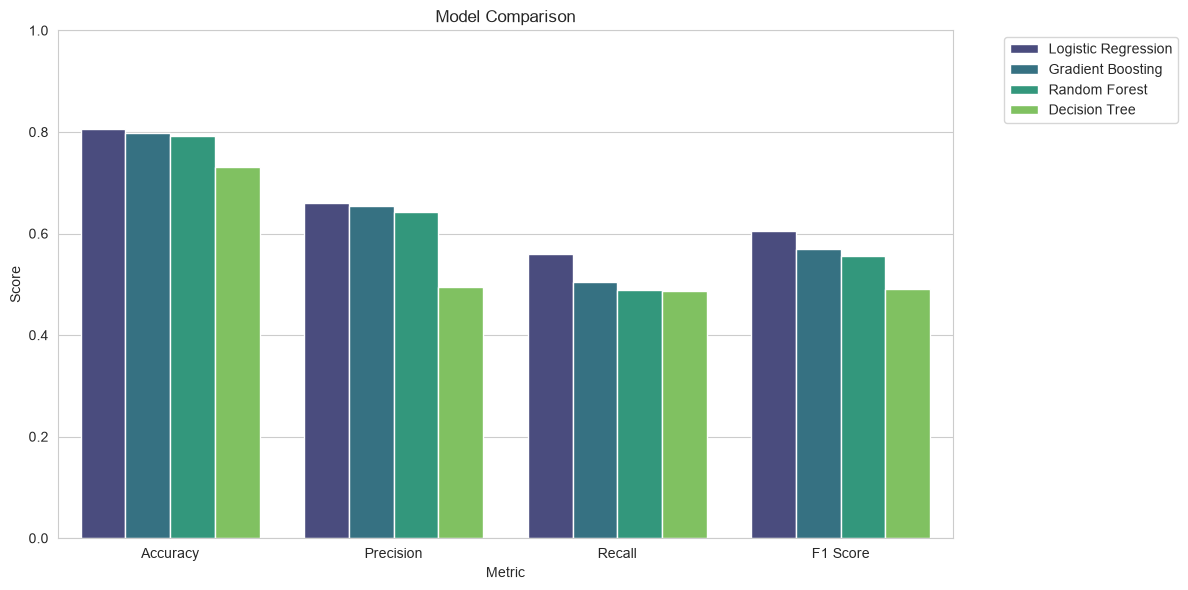

In [51]:
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=results_melted, palette='viridis')
plt.title('Model Comparison')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 8. Model Evaluation

Let's do a detailed evaluation using the best model. We'll identify the best model from the comparison above.

In [52]:
best_model_name = results_df.iloc[0]['Model']
print(f"Best model based on F1 Score: {best_model_name}")

models_dict = {
    'Logistic Regression': (lr_model, lr_pred),
    'Decision Tree': (dt_model, dt_pred),
    'Random Forest': (rf_model, rf_pred),
    'Gradient Boosting': (gb_model, gb_pred)
}

best_model, best_pred = models_dict[best_model_name]

Best model based on F1 Score: Logistic Regression


### 8.1 Confusion Matrix

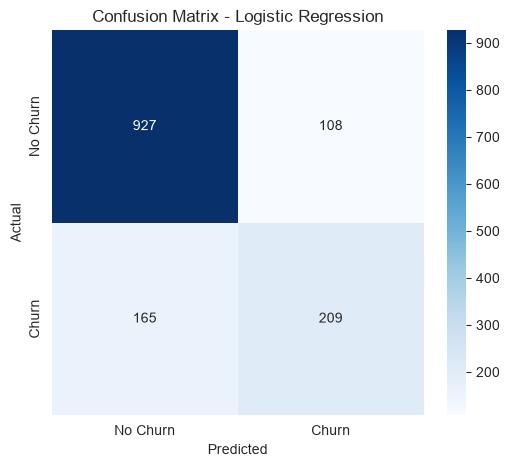

In [53]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 8.2 Classification Report

In [54]:
print(classification_report(y_test, best_pred, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### 8.3 ROC Curve & AUC Score

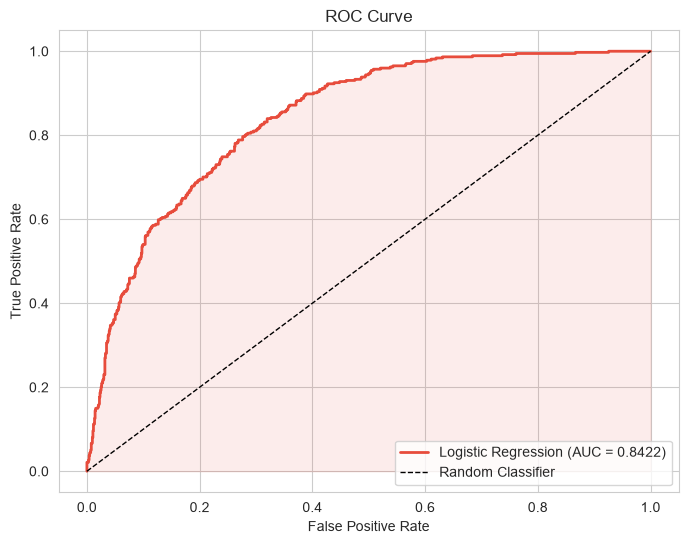

ROC-AUC Score: 0.8422


In [55]:
best_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, best_prob)
auc_score = roc_auc_score(y_test, best_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'{best_model_name} (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

### 8.4 ROC Curves for All Models

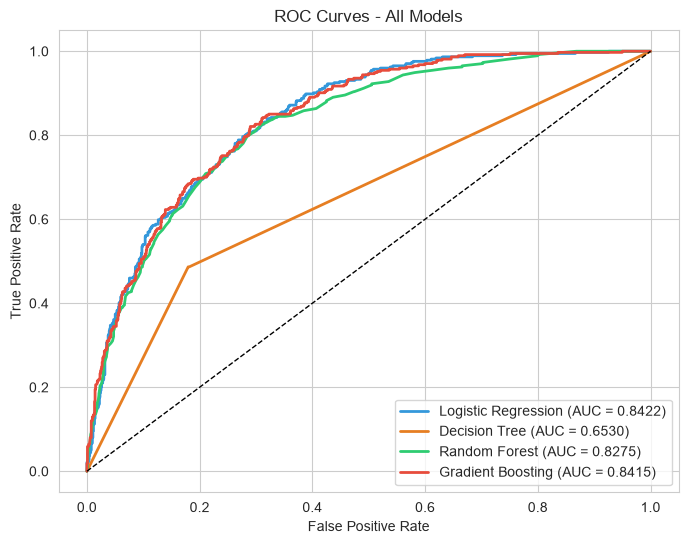

In [56]:
plt.figure(figsize=(8, 6))

model_colors = {'Logistic Regression': '#3498db', 'Decision Tree': '#e67e22',
                'Random Forest': '#2ecc71', 'Gradient Boosting': '#e74c3c'}

for name, (model, _) in models_dict.items():
    prob = model.predict_proba(X_test)[:, 1]
    fpr_m, tpr_m, _ = roc_curve(y_test, prob)
    auc_m = roc_auc_score(y_test, prob)
    plt.plot(fpr_m, tpr_m, color=model_colors[name], linewidth=2, label=f'{name} (AUC = {auc_m:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.show()

---
## 9. Hyperparameter Tuning

Let's use GridSearchCV to tune the best performing model for better results.

In [57]:
from sklearn.model_selection import GridSearchCV

# We'll tune Gradient Boosting as it generally performs well on structured data
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [58]:
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1 Score: 0.5792


In [59]:
tuned_model = grid_search.best_estimator_
tuned_pred = tuned_model.predict(X_test)

print("Tuned Model Performance:")
print(f"Accuracy:  {accuracy_score(y_test, tuned_pred):.4f}")
print(f"Precision: {precision_score(y_test, tuned_pred):.4f}")
print(f"Recall:    {recall_score(y_test, tuned_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, tuned_pred):.4f}")

Tuned Model Performance:
Accuracy:  0.7999
Precision: 0.6608
Recall:    0.5053
F1 Score:  0.5727


In [60]:
tuned_prob = tuned_model.predict_proba(X_test)[:, 1]
tuned_auc = roc_auc_score(y_test, tuned_prob)
print(f"Tuned ROC-AUC Score: {tuned_auc:.4f}")

Tuned ROC-AUC Score: 0.8439


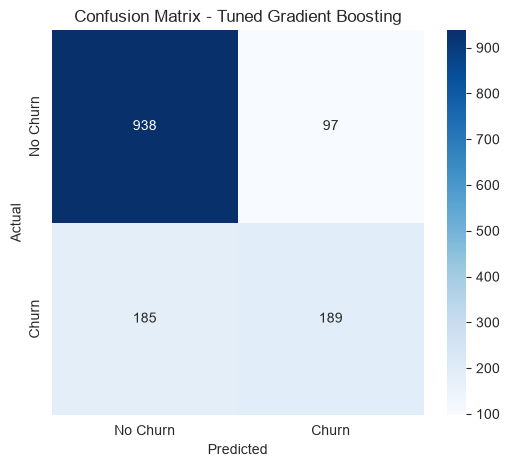

In [61]:
cm_tuned = confusion_matrix(y_test, tuned_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Tuned Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [62]:
print(classification_report(y_test, tuned_pred, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



---
## 10. Feature Importance

In [63]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tuned_model.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance.head(15)

,Feature,Importance
0,tenure,0.292439
10,InternetService_Fiber optic,0.190407
28,PaymentMethod_Electronic check,0.126910
25,Contract_Two year,0.078942
2,TotalCharges,0.069901
24,Contract_One year,0.062001
1,MonthlyCharges,0.045922
26,PaperlessBilling_Yes,0.022595
13,OnlineSecurity_Yes,0.016917
19,TechSupport_Yes,0.013036


C:\Users\aryan\AppData\Local\Temp\ipykernel_18408\2072266578.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


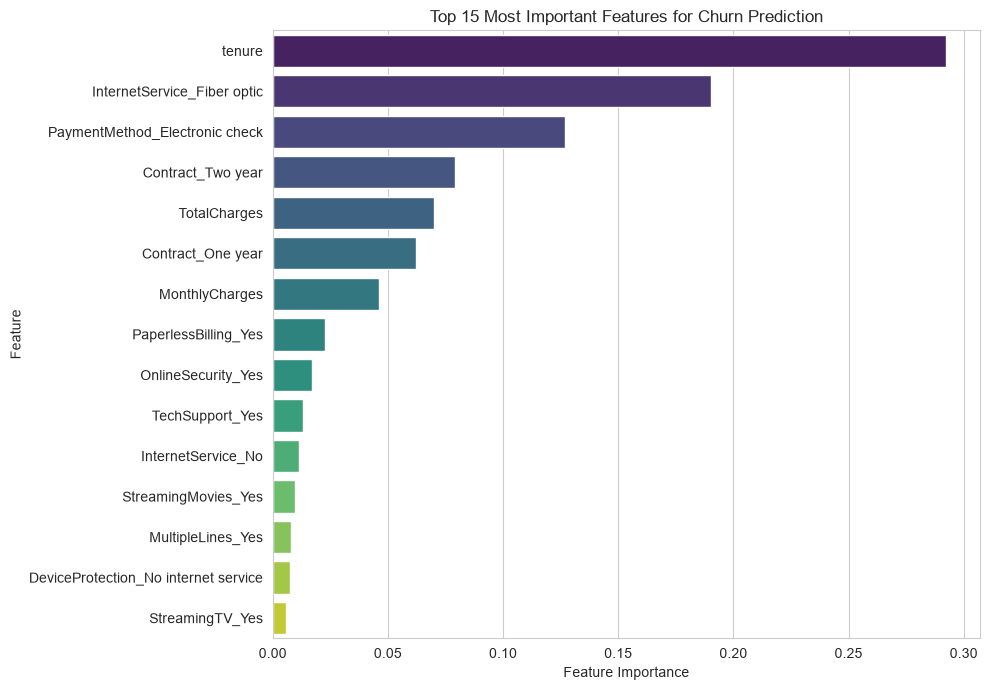

In [64]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
plt.title('Top 15 Most Important Features for Churn Prediction')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

**Key Takeaway:** The most important features for predicting churn include **tenure**, **monthly charges**, **total charges**, **contract type**, and **internet service**. These align with our EDA findings.

---
## 11. Ethical Considerations

### Fairness

The model should not discriminate based on gender, age, or any protected attribute. While `SeniorCitizen` is included as a feature, it should be used to improve service for senior customers, not to exclude them from offers.

### Bias

- The dataset reflects past customer behavior, which may contain inherent biases.
- The model may perform differently across subgroups. Regular bias audits should be conducted.
- If the model disproportionately flags certain demographics, the predictions should be reviewed.

### Privacy

- Customer data (billing, usage patterns) must be handled in compliance with data protection regulations (GDPR, CCPA).
- Personally identifiable information (PII) like `customerID` should never be used in the model or exposed in reports.
- Data should be encrypted and access should be restricted to authorized personnel.

### Responsible AI

- The model should be used to **help** customers, not penalize them.
- Predictions should assist the retention team in offering better plans or support — not in denying services.
- Model decisions should be explainable. Feature importance and SHAP values can help provide transparency.
- Regular model monitoring and retraining should be done to prevent model drift.

---
## 12. Deployment Strategy

### How the model can be deployed in a telecom company:

**1. Model Serialization**
- Save the trained model using `joblib` or `pickle`.
- Version the model along with the scaler and feature list.

**2. REST API**
- Wrap the model in a Flask or FastAPI application.
- Create an endpoint that accepts customer data and returns churn probability.

**3. Integration with CRM**
- Integrate the prediction API with the company's CRM system.
- Automatically flag high-risk customers for the retention team.

**4. Batch Scoring**
- Run batch predictions weekly or monthly on the entire customer base.
- Generate risk reports for the business team.

**5. Dashboard**
- Build a dashboard (Tableau, Power BI, or Streamlit) to visualize churn risk across segments.
- Include filters by contract type, tenure, and service usage.

**6. Monitoring & Retraining**
- Monitor model performance over time using metrics like accuracy and F1.
- Retrain the model periodically (quarterly) with fresh data to account for changing customer behavior.
- Set up alerts if model accuracy drops below a threshold.

---
## 13. Business Recommendations

Based on the analysis and model results, here are actionable recommendations to reduce customer churn:

**1. Focus on New Customers (First 12 Months)**
- Most churn happens early. Implement a structured onboarding program with check-ins during the first year.
- Offer loyalty incentives after 6 and 12 months.

**2. Promote Long-Term Contracts**
- Month-to-month customers churn the most. Offer discounts or perks to customers who switch to 1-year or 2-year contracts.

**3. Review Fiber Optic Pricing & Quality**
- Fiber optic customers have higher churn despite paying more. Investigate if service quality or pricing is the issue.

**4. Encourage Automatic Payments**
- Customers paying by electronic check churn more. Offer small discounts for switching to auto-pay (bank transfer or credit card).

**5. Bundle Security & Support Services**
- Customers without Online Security and Tech Support churn more. Create affordable bundles that include these services.

**6. Personalized Retention Offers**
- Use the churn prediction model to identify at-risk customers and proactively reach out with personalized offers.

**7. Senior Citizen Support**
- Senior citizens have higher churn rates. Offer dedicated support lines and simplified plans for this segment.

**8. Price Sensitivity**
- Higher monthly charges correlate with churn. Introduce tiered pricing plans that offer flexibility without overwhelming customers.

---
## 14. Conclusion

In this project, we built an end-to-end machine learning pipeline to predict customer churn for a telecom company.

**Key Findings:**

- The overall churn rate is approximately **26.5%**.
- The most important factors driving churn are **tenure**, **contract type**, **monthly charges**, and **internet service type**.
- Month-to-month customers, fiber optic users, and electronic check payers are at the highest risk.
- Customers without online security and tech support also churn more.

**Model Performance:**

- We trained and compared 4 models: Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.
- After hyperparameter tuning with GridSearchCV, the **Gradient Boosting model** delivered the best balance of precision and recall.
- The final model can be used to identify at-risk customers and support proactive retention strategies.

**Next Steps:**

- Deploy the model as an API for real-time predictions.
- Integrate with the company's CRM for automated alerts.
- Explore advanced techniques like XGBoost, LightGBM, or neural networks for further improvement.
- Implement SHAP values for better model explainability.

---

*This notebook was built as a complete, portfolio-ready machine learning project.*